# 1.라이브러리 및 데이터 불러오기
- https://archive.ics.uci.edu/dataset/352/online+retail

In [1]:
import pandas as pd
import numpy as np
import datetime
import math
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# %pip install openpyxl

In [3]:
retail_df = pd.read_excel('data1/Online Retail.xlsx')
retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# 2.데이터 확인

In [4]:
retail_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
retail_df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


# 3.데이터 전처리

In [6]:
retail_df = retail_df[retail_df['Quantity']>0]
retail_df = retail_df[retail_df['UnitPrice']>0]
retail_df = retail_df.dropna()
retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
retail_df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [8]:
retail_df['Country'].value_counts()

Country
United Kingdom          354321
Germany                   9040
France                    8341
EIRE                      7236
Spain                     2484
Netherlands               2359
Belgium                   2031
Switzerland               1841
Portugal                  1462
Australia                 1182
Norway                    1071
Italy                      758
Channel Islands            748
Finland                    685
Cyprus                     614
Sweden                     451
Austria                    398
Denmark                    380
Poland                     330
Japan                      321
Israel                     248
Unspecified                244
Singapore                  222
Iceland                    182
USA                        179
Canada                     151
Greece                     145
Malta                      112
United Arab Emirates        68
European Community          60
RSA                         57
Lebanon                     45


In [ ]:
# 37개국에서 주문
len(retail_df['Country'].unique())

37

In [10]:
# 주문 금액 데이터 만들기
retail_df['sale_amount'] = retail_df['Quantity'] * retail_df['UnitPrice']
retail_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,sale_amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [12]:
retail_df['CustomerID'] = retail_df['CustomerID'].astype('int')

In [13]:
# RFM은 '누가 우리에게 중요한 고객인가?'를 아주 간단한 3개의 지표로 가려내는 고객 가치 세분화 방법.
# Recency(R) : 가장 최근 상품 구입일에서 오늘까지의 기간    -> 현재 뜨거운 고객
# Frequency(F) : 상품 구매 횟수                         -> 충성/관계 깊음
# Monetary value(M) : 총 구매 금액                      -> 가치 높음

In [14]:
# Top-5 주문 건수 고객 데이터 추출
retail_df['CustomerID'].value_counts().head()

CustomerID
17841    7847
14911    5675
14096    5111
12748    4595
14606    2700
Name: count, dtype: int64

In [15]:
# Top-5 주문 금액을 가진 고객 데이터 추출
retail_df.groupby('CustomerID')['sale_amount'].sum().sort_values(ascending=False)[:5]

CustomerID
14646    280206.02
18102    259657.30
17450    194550.79
16446    168472.50
14911    143825.06
Name: sale_amount, dtype: float64

In [16]:
aggregation = {
    'sale_amount' : 'sum',  # M
    'InvoiceNo' : 'count',  # F
    'InvoiceDate' : 'max'   # R
}

cust_df = retail_df.groupby('CustomerID').agg(aggregation)
cust_df

,sale_amount,InvoiceNo,InvoiceDate
CustomerID,,,
12346,77183.60,1,2011-01-18 10:01:00
12347,4310.00,182,2011-12-07 15:52:00
12348,1797.24,31,2011-09-25 13:13:00
12349,1757.55,73,2011-11-21 09:51:00
12350,334.40,17,2011-02-02 16:01:00
...,...,...,...
18280,180.60,10,2011-03-07 09:52:00
18281,80.82,7,2011-06-12 10:53:00
18282,178.05,12,2011-12-02 11:43:00


In [17]:
import datetime as dt

# 현재 날짜(2011-12-10)와 차이
cust_df['InvoiceDate'] = dt.datetime(2011,12,10) - cust_df['InvoiceDate']

In [18]:
cust_df.head()

,sale_amount,InvoiceNo,InvoiceDate
CustomerID,,,
12346,77183.60,1,325 days 13:59:00
12347,4310.00,182,2 days 08:08:00
12348,1797.24,31,75 days 10:47:00
12349,1757.55,73,18 days 14:09:00
12350,334.40,17,310 days 07:59:00


In [19]:
# 일 수(day)를 정수로 추출. 마지막 구매 이후 경과된 일 수(Recency)
# 값이 작으면 최근에 구매. 크다면 오래 전에 구매. 휴면 고객 또는 이탈 위험 고객일 가능성.

cust_df['InvoiceDate'] = cust_df['InvoiceDate'].dt.days
cust_df.head()

,sale_amount,InvoiceNo,InvoiceDate
CustomerID,,,
12346,77183.60,1,325
12347,4310.00,182,2
12348,1797.24,31,75
12349,1757.55,73,18
12350,334.40,17,310


# 4.스케일링

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaled_data = StandardScaler().fit_transform(cust_df)
scaled_data

array([[ 8.35866818e+00, -3.96577702e-01,  2.32938811e+00],
       [ 2.50966264e-01,  3.94648958e-01, -9.00588115e-01],
       [-2.85960063e-02, -2.65435162e-01, -1.70593488e-01],
       ...,
       [-2.08742313e-01, -3.48492104e-01, -8.50588483e-01],
       [ 4.51854273e-03,  2.90384290e+00, -8.90588188e-01],
       [-2.41412739e-02, -9.49498596e-02, -5.00591059e-01]],
      shape=(4338, 3))

# 5.모델링

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

In [23]:
kmeans = KMeans(n_clusters=3, random_state=1)
kmeans.fit(scaled_data)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",1
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [24]:
cust_df['cluster'] = kmeans.labels_
cust_df

,sale_amount,InvoiceNo,InvoiceDate,cluster
CustomerID,,,,
12346,77183.60,1,325,1
12347,4310.00,182,2,0
12348,1797.24,31,75,0
12349,1757.55,73,18,0
12350,334.40,17,310,1
...,...,...,...,...
18280,180.60,10,277,1
18281,80.82,7,180,1
18282,178.05,12,7,0


In [25]:
silhouette_score(scaled_data, kmeans.labels_)

0.6018678448358709

# 6.최적의 고객 군집 찾기

In [28]:
# 실루엣 계수 저장을 위한 리스트 생성
silhouette_score_list = []

# 군집 개수 k를 2~10까지 테스트
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(scaled_data)
    score = silhouette_score(scaled_data, kmeans.labels_)
    silhouette_score_list.append(score)
    print(f'cluster :{k}, silhouttet score :{score:.3f}')

cluster :2, silhouttet score :0.576
cluster :3, silhouttet score :0.602
cluster :4, silhouttet score :0.600
cluster :5, silhouttet score :0.617
cluster :6, silhouttet score :0.592
cluster :7, silhouttet score :0.552
cluster :8, silhouttet score :0.511
cluster :9, silhouttet score :0.510
cluster :10, silhouttet score :0.481


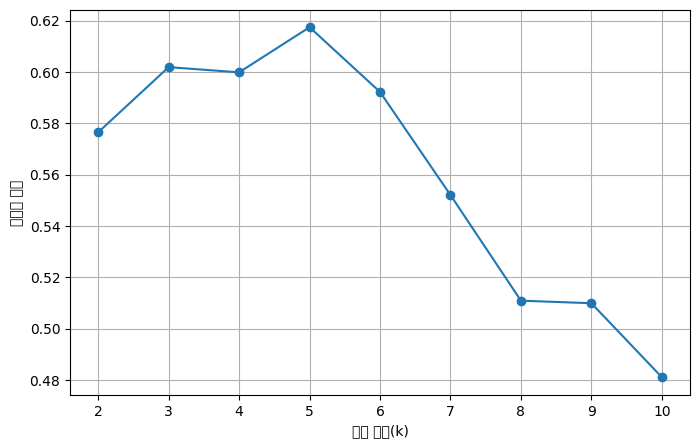

In [29]:
# 결과 시각화
plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_score_list, marker='o')

plt.xlabel('군집 개수(k)')
plt.ylabel('실루엣 계수')
plt.grid()
plt.show()